In [30]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

In [18]:
df = pd.DataFrame({
    'DAY': ['D1','D2','D3','D4','D5','D6','D7',
            'D8','D9','D10','D11','D12','D13','D14'],

    'Outlook': ['SUNNY','SUNNY','SUNNY','RAIN','RAIN',
                'OVERCAST','OVERCAST','SUNNY','RAIN',
                'RAIN','OVERCAST','RAIN','OVERCAST','SUNNY'],

    'Temperature': ['HOT','HOT','HOT','MILD','COOL',
                    'COOL','MILD','COOL','MILD',
                    'COOL','COOL','MILD','HOT','MILD'],

    'Humidity':  ['HIGH','HIGH','HIGH','HIGH','NORMAL','NORMAL',
                'NORMAL','HIGH','NORMAL','NORMAL','NORMAL',
                'HIGH','NORMAL','HIGH'],       

    'Wind':     ['WEAK','STRONG','WEAK','WEAK','WEAK',  
                'STRONG','STRONG','WEAK','WEAK','WEAK',
                'STRONG','STRONG','WEAK','STRONG'] ,

    'Play Golf':['NO','NO','YES','YES','YES','NO',
                'YES','NO','YES','YES','YES','YES','YES','NO']                                     
})

print("--- Original DataFrame ---")
print(df)

--- Original DataFrame ---
    DAY   Outlook Temperature Humidity    Wind Play Golf
0    D1     SUNNY         HOT     HIGH    WEAK        NO
1    D2     SUNNY         HOT     HIGH  STRONG        NO
2    D3     SUNNY         HOT     HIGH    WEAK       YES
3    D4      RAIN        MILD     HIGH    WEAK       YES
4    D5      RAIN        COOL   NORMAL    WEAK       YES
5    D6  OVERCAST        COOL   NORMAL  STRONG        NO
6    D7  OVERCAST        MILD   NORMAL  STRONG       YES
7    D8     SUNNY        COOL     HIGH    WEAK        NO
8    D9      RAIN        MILD   NORMAL    WEAK       YES
9   D10      RAIN        COOL   NORMAL    WEAK       YES
10  D11  OVERCAST        COOL   NORMAL  STRONG       YES
11  D12      RAIN        MILD     HIGH  STRONG       YES
12  D13  OVERCAST         HOT   NORMAL    WEAK       YES
13  D14     SUNNY        MILD     HIGH  STRONG        NO


In [19]:
df.shape

(14, 6)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   DAY          14 non-null     object
 1   Outlook      14 non-null     object
 2   Temperature  14 non-null     object
 3   Humidity     14 non-null     object
 4   Wind         14 non-null     object
 5   Play Golf    14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [21]:
df.describe()

,DAY,Outlook,Temperature,Humidity,Wind,Play Golf
count,14,14,14,14,14,14
unique,14,3,3,2,2,2
top,D1,SUNNY,MILD,HIGH,WEAK,YES
freq,1,5,5,7,8,9


In [22]:
label_encoder = LabelEncoder()
df['Outlook'] = label_encoder.fit_transform(df['Outlook'])
df['Temperature'] = label_encoder.fit_transform(df['Temperature'])
df['Humidity'] = label_encoder.fit_transform(df['Humidity'])
df['Wind'] = label_encoder.fit_transform(df['Wind'])
df['Play Golf'] = label_encoder.fit_transform(df['Play Golf'])

print("\n--- Encoded DataFrame ---")
print(df)



--- Encoded DataFrame ---
    DAY  Outlook  Temperature  Humidity  Wind  Play Golf
0    D1        2            1         0     1          0
1    D2        2            1         0     0          0
2    D3        2            1         0     1          1
3    D4        1            2         0     1          1
4    D5        1            0         1     1          1
5    D6        0            0         1     0          0
6    D7        0            2         1     0          1
7    D8        2            0         0     1          0
8    D9        1            2         1     1          1
9   D10        1            0         1     1          1
10  D11        0            0         1     0          1
11  D12        1            2         0     0          1
12  D13        0            1         1     1          1
13  D14        2            2         0     0          0


In [23]:

X = df[['Outlook','Temperature','Humidity','Wind']]
y = df['Play Golf']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred=clf.predict(X_test)
score=accuracy_score(y_test,y_pred)
score

0.6666666666666666

In [32]:
class_report = classification_report(y_test, y_pred, zero_division=1)
print(f"\nClassification Report :\n{class_report}") 
  


Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.83      0.50      0.40         3
weighted avg       0.78      0.67      0.53         3



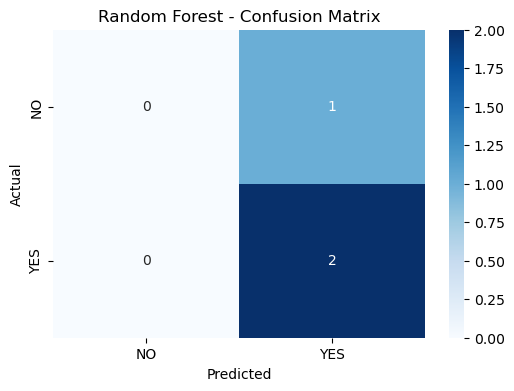

In [33]:
cfm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cfm, annot=True, fmt="d", cmap="Blues", xticklabels=['NO','YES'], yticklabels=['NO','YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

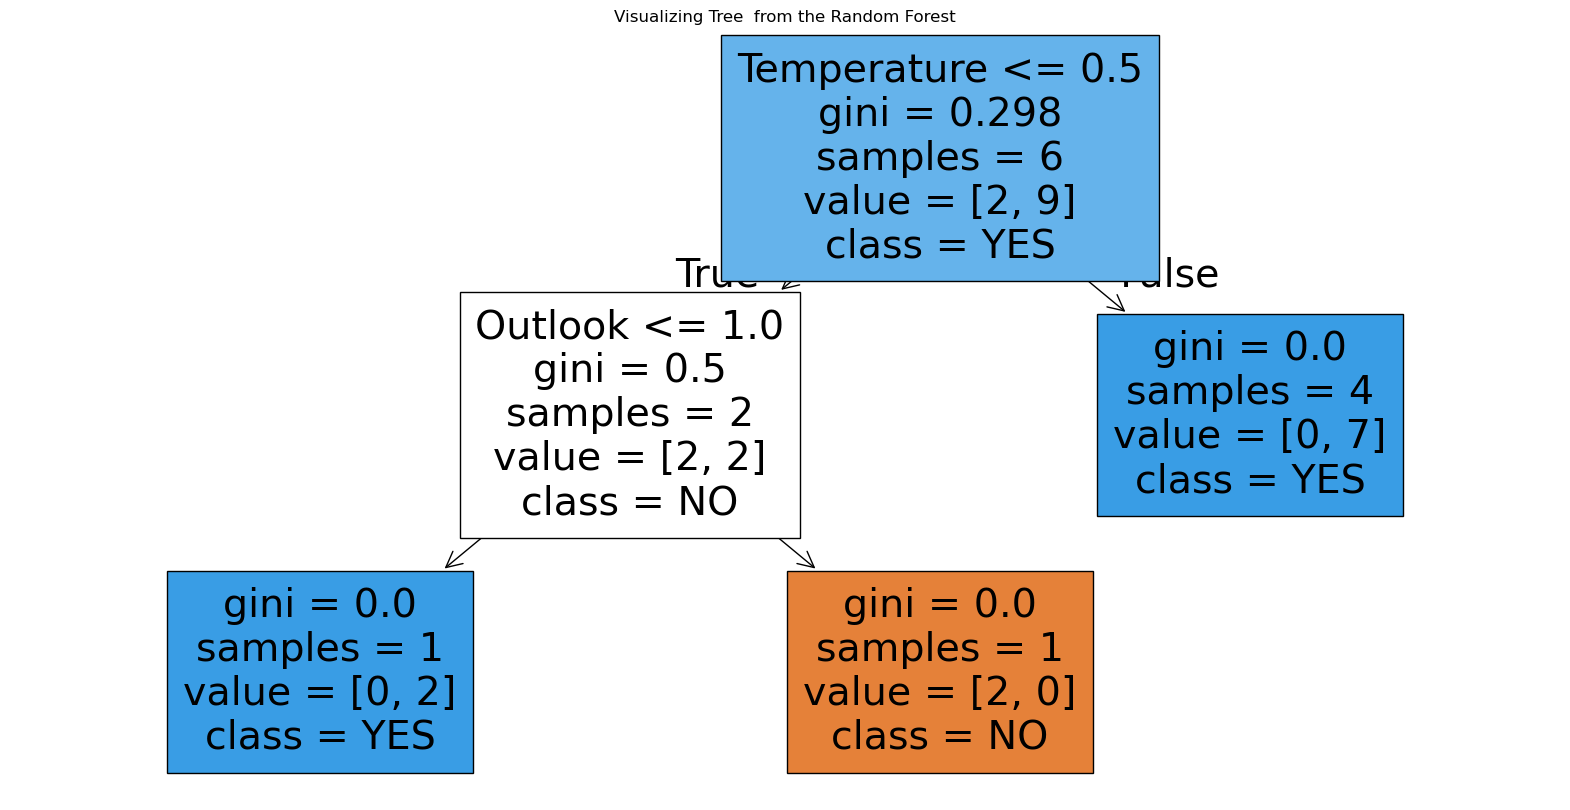

In [34]:


plt.figure(figsize=(20,10))
tree.plot_tree(clf.estimators_[0], filled=True, feature_names=X.columns, class_names=['NO','YES'])
plt.title("Visualizing Tree  from the Random Forest")
plt.show()